*heteroTests tutorial series — **01. Detecting heteroscedasticity** · [02. Remediation](02-remediating-heteroscedasticity.ipynb) · [03. Modern & scalable diagnostics](03-modern-and-scalable.ipynb) · [04. Group-wise variance tests](04-group-wise-variance.ipynb) · [05. Time series & ARCH effects](05-time-series-arch.ipynb) · [06. Choosing a test: a power study](06-choosing-a-test.ipynb)*


# Detecting Heteroscedasticity in Linear Models

**A practitioner's guide using the `heteroTests` package**

---

Ordinary least squares (OLS) remains unbiased under heteroscedasticity, but its
standard errors do not: the usual covariance estimator
$\hat\sigma^2 (X^\top X)^{-1}$ assumes a constant error variance
$\operatorname{Var}(\varepsilon_i)=\sigma^2$. When that assumption fails, the
reported standard errors, $t$-statistics, $p$-values and confidence intervals
are no longer valid, and conclusions drawn from them can be wrong.

This notebook works through a complete diagnostic pass on a classic, genuinely
heteroscedastic data set:

1. **Quantify the cost** of ignoring non-constant variance.
2. **Diagnose visually** with residual plots.
3. **Test formally** with the White, Breusch--Pagan and Koenker tests,
   understanding what each can and cannot detect.
4. **Cross-validate** the implementation against `lmtest`.

Every result below is computed live; a `sessionInfo()` block at the end records
the exact environment.


In [1]:
library(heteroTests)
ht_set_log_level("SILENT")  # keep simulation loops quiet
library(ggplot2)
theme_set(theme_minimal(base_size = 12))
options(digits = 4)


Warning message:
"package 'ggplot2' was built under R version 4.5.3"


## 1. The data and the fitted model

We model the median home value (`medv`, in \$1{,}000s) for 506 Boston census
tracts as a function of four well-understood predictors: the share of
lower-status population (`lstat`), average number of rooms (`rm`), per-capita
crime (`crim`) and distance to employment centres (`dis`). This data set is a
textbook example of variance that grows with the fitted value.


In [2]:
data(boston_housing, package = "heteroTests")
model <- lm(medv ~ lstat + rm + crim + dis, data = boston_housing)
summary(model)



Call:
lm(formula = medv ~ lstat + rm + crim + dis, data = boston_housing)

Residuals:
   Min     1Q Median     3Q    Max 
-19.01  -3.10  -1.05   1.88  26.57 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   2.2306     3.3221    0.67      0.5    
lstat        -0.6617     0.0510  -12.97  < 2e-16 ***
rm            4.9765     0.4389   11.34  < 2e-16 ***
crim         -0.1281     0.0321   -3.99  7.5e-05 ***
dis          -0.5632     0.1354   -4.16  3.8e-05 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 5.4 on 501 degrees of freedom
Multiple R-squared:  0.658,	Adjusted R-squared:  0.655 
F-statistic:  241 on 4 and 501 DF,  p-value: <2e-16


All four predictors are highly significant *as reported by OLS*. Hold that
thought: the next section shows those standard errors are optimistic.


## 2. What heteroscedasticity costs you

If the error variance is not constant, the model-based covariance matrix is the
wrong one. A heteroscedasticity-consistent (HC) sandwich estimator,

$$\widehat{\operatorname{Var}}_{\text{HC}}(\hat\beta)=(X^\top X)^{-1}
\Big(\textstyle\sum_i \omega_i\, e_i^2\, x_i x_i^\top\Big)(X^\top X)^{-1},$$

remains valid without assuming constant variance. Comparing the two tells us
how badly the classical standard errors are biased here. The package's
`performHCCovarianceTest()` formalises this comparison; below we also tabulate
the standard errors side by side.


In [3]:
hc <- performHCCovarianceTest(model, boston_housing, type = "HC3")
hc



	Heteroscedasticity-consistent covariance test (HC3)

data:  medv ~ lstat + rm + crim + dis
X-squared = 31, df = 4, p-value = 3e-06
sample estimates:
mean_adjusted_residual 
                 29.91 


In [4]:
# Classical OLS vs. HC3 (robust) standard errors, coefficient by coefficient
V_ols <- vcov(model)
X     <- model.matrix(model)
e     <- residuals(model)
h     <- hatvalues(model)
meat  <- crossprod(X, (e^2 / (1 - h)^2) * X)   # HC3 meat
V_hc3 <- solve(crossprod(X)) %*% meat %*% solve(crossprod(X))
se_ols <- sqrt(diag(V_ols)); se_hc3 <- sqrt(diag(V_hc3))
data.frame(
  term       = names(coef(model)),
  estimate   = round(coef(model), 3),
  se_OLS     = round(se_ols, 3),
  se_HC3     = round(se_hc3, 3),
  inflation  = round(se_hc3 / se_ols, 2),
  row.names  = NULL)


term,estimate,se_OLS,se_HC3,inflation
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),2.231,3.322,6.110,1.84
lstat,-0.662,0.051,0.088,1.73
rm,4.976,0.439,0.796,1.81
crim,-0.128,0.032,0.030,0.94
dis,-0.563,0.135,0.170,1.25


Warning message:
"`geom_errorbarh()` was deprecated in ggplot2 4.0.0.
ℹ Please use the `orientation` argument of `geom_errorbar()` instead."


`height` was translated to `width`.


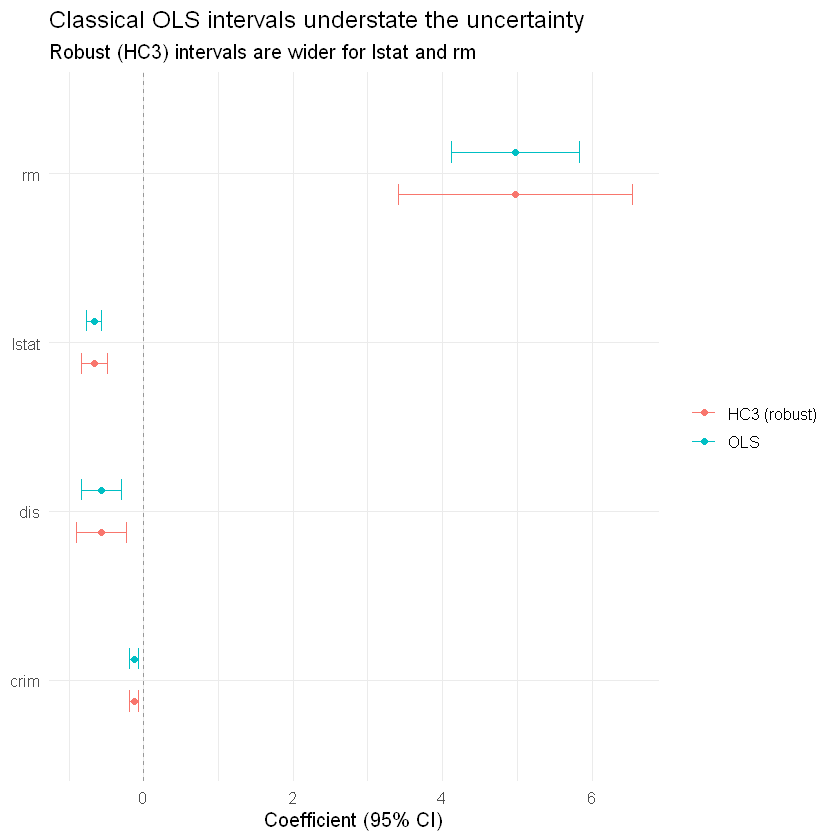

In [5]:
# Visualise the same story: 95% intervals, classical vs robust
ints <- rbind(
  data.frame(term = names(coef(model)), est = coef(model),
             lo = coef(model) - 1.96 * se_ols, hi = coef(model) + 1.96 * se_ols,
             kind = "OLS"),
  data.frame(term = names(coef(model)), est = coef(model),
             lo = coef(model) - 1.96 * se_hc3, hi = coef(model) + 1.96 * se_hc3,
             kind = "HC3 (robust)"))
ints <- subset(ints, term != "(Intercept)")
ggplot(ints, aes(est, term, colour = kind)) +
  geom_vline(xintercept = 0, linetype = "dashed", colour = "grey60") +
  geom_point(position = position_dodge(width = 0.5)) +
  geom_errorbarh(aes(xmin = lo, xmax = hi), height = 0.25,
                 position = position_dodge(width = 0.5)) +
  labs(x = "Coefficient (95% CI)", y = NULL, colour = NULL,
       title = "Classical OLS intervals understate the uncertainty",
       subtitle = "Robust (HC3) intervals are wider for lstat and rm")


The robust standard errors for `lstat` and `rm` are roughly **1.8&times;** the
OLS values. The OLS covariance estimator understates the true sampling
variability by almost a factor of two for the most important coefficients --- a
direct, quantitative consequence of the non-constant error variance. Inference
that ignores it is over-confident.


## 3. Visual diagnosis

Before any test, look at the residuals. Under homoscedasticity the residual
cloud should have constant vertical spread across the fitted values. A widening
(funnel) shape is the signature of variance that grows with the mean.


`geom_smooth()` using formula = 'y ~ x'


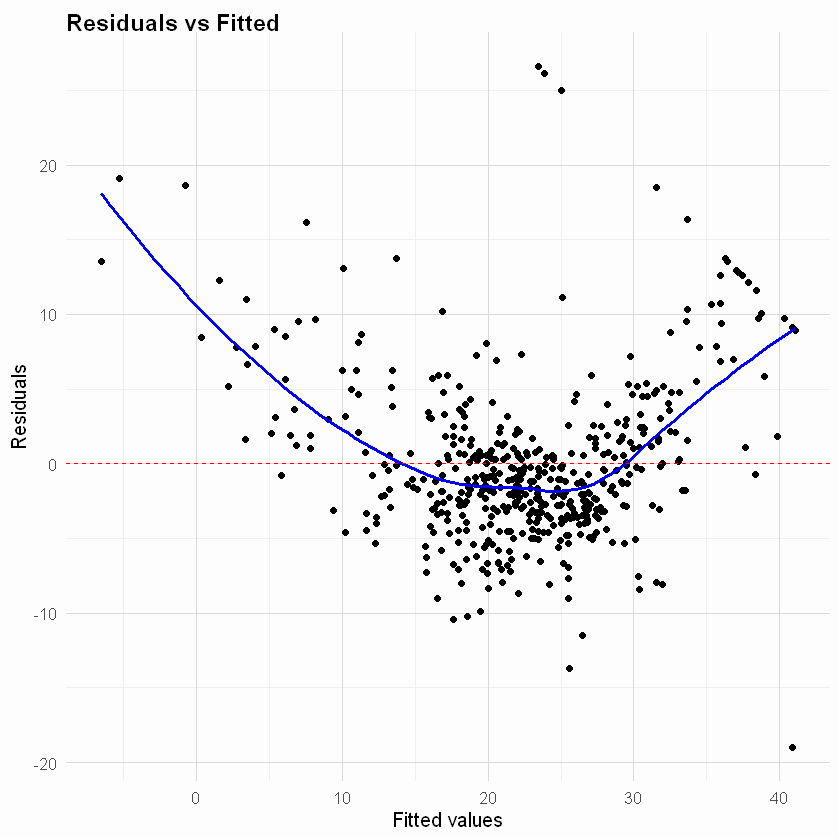

In [6]:
plotResidualsFitted(model)


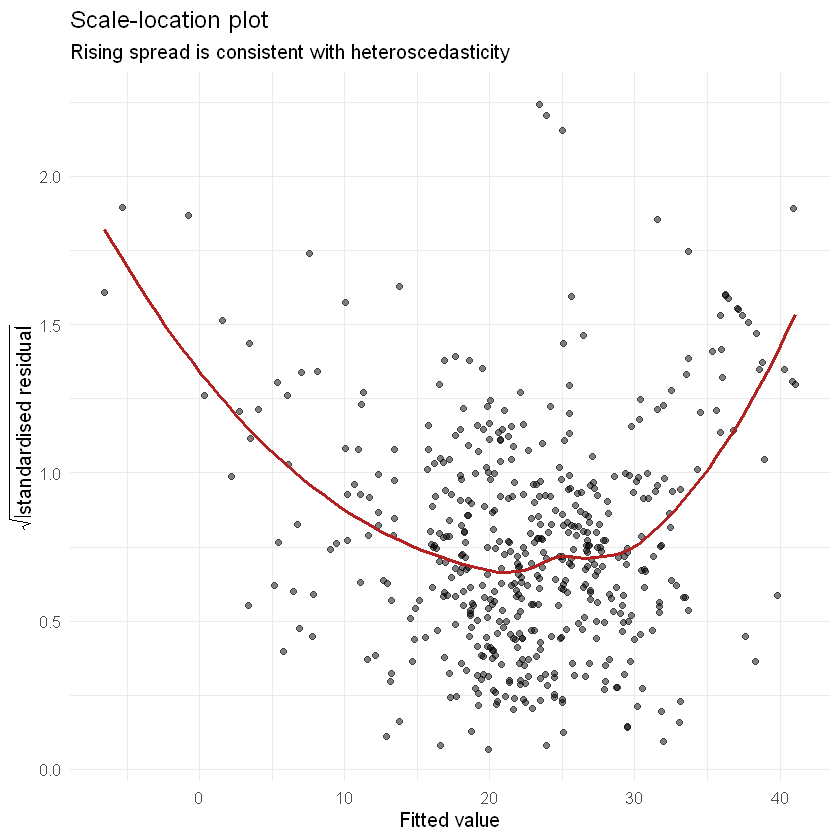

In [7]:
# Scale-location view: sqrt(|standardised residual|) vs fitted value.
# An upward trend in the smoother indicates increasing spread.
sl <- data.frame(fitted = fitted(model),
                 root_abs = sqrt(abs(rstandard(model))))
ggplot(sl, aes(fitted, root_abs)) +
  geom_point(alpha = 0.5) +
  geom_smooth(method = "loess", formula = y ~ x, se = FALSE,
              colour = "firebrick") +
  labs(x = "Fitted value", y = expression(sqrt(abs("standardised residual"))),
       title = "Scale-location plot",
       subtitle = "Rising spread is consistent with heteroscedasticity")


Both plots show clearly increasing dispersion: tracts with higher predicted
values have much more variable residuals. This is the pattern the formal tests
are designed to detect.


## 4. Formal tests

Visual evidence should be confirmed with a test. The three auxiliary-regression
tests below differ in *what variance pattern they look for*, which is exactly
why it pays to run more than one.

Let $e_i$ be the OLS residuals and $Z$ the matrix of regressors.

| Test | Auxiliary regression | Statistic | Detects |
|------|----------------------|-----------|---------|
| **White** | $e_i^2$ on $Z$, its squares and cross-products | $nR^2 \sim \chi^2_q$ | general (incl. nonlinear) variance |
| **Breusch--Pagan** (classical) | scaled $e_i^2$ on $Z$ | $\tfrac12\,\text{ESS} \sim \chi^2_p$ | variance linear in $Z$; assumes normality |
| **Koenker** (studentized BP) | $e_i^2$ on $Z$ | $nR^2 \sim \chi^2_p$ | variance linear in $Z$; robust to non-normality |

In `heteroTests`, `performBPTest()` is the classical statistic
(`lmtest::bptest(studentize = FALSE)`) and `performKoenkerTest()` is the
studentized one (`studentize = TRUE`); they are distinct statistics, not
aliases.


In [8]:
white   <- performWhiteTest(model, boston_housing)
bp      <- performBPTest(model, boston_housing)
koenker <- performKoenkerTest(model, boston_housing)
white



	White's test for heteroscedasticity

data:  model
X-squared = 194, df = 14, p-value <2e-16
alternative hypothesis: heteroscedasticity present


In [9]:
bp
koenker



	Breusch-Pagan test for heteroscedasticity

data:  medv ~ lstat + rm + crim + dis
X-squared = 89, df = 4, p-value <2e-16



	Koenker studentized Breusch-Pagan test

data:  medv ~ lstat + rm + crim + dis
X-squared = 31, df = 4, p-value = 3e-06


### Cross-validation against `lmtest`

A correctness check: the classical statistic must reproduce
`lmtest::bptest(studentize = FALSE)` and the Koenker statistic the default
`studentize = TRUE`, to machine precision.


In [10]:
data.frame(
  comparison = c("performBPTest vs bptest(studentize = FALSE)",
                 "performKoenkerTest vs bptest(studentize = TRUE)"),
  agree = c(
    isTRUE(all.equal(unname(bp$statistic),
                     unname(lmtest::bptest(model, studentize = FALSE)$statistic))),
    isTRUE(all.equal(unname(koenker$statistic),
                     unname(lmtest::bptest(model, studentize = TRUE)$statistic)))))


comparison,agree
<chr>,<lgl>
performBPTest vs bptest(studentize = FALSE),TRUE
performKoenkerTest vs bptest(studentize = TRUE),TRUE


## 5. Putting it together

A compact summary table is the natural artefact to carry into a report.


In [11]:
summarise_test <- function(x, label) data.frame(
  Test = label, Statistic = round(unname(x$statistic), 2),
  df = unname(x$parameter), p.value = signif(x$p.value, 3),
  Reject_5pct = x$p.value < 0.05)
do.call(rbind, list(
  summarise_test(white,   "White (general)"),
  summarise_test(bp,      "Breusch-Pagan (classical)"),
  summarise_test(koenker, "Koenker (studentized)")))


Test,Statistic,df,p.value,Reject_5pct
<chr>,<dbl>,<int>,<dbl>,<lgl>
White (general),193.77,14,1.02e-33,TRUE
Breusch-Pagan (classical),88.53,4,2.70e-18,TRUE
Koenker (studentized),31.03,4,3.02e-06,TRUE


## 6. Takeaways

- For these data **every test rejects homoscedasticity decisively**, confirming
  the funnel seen in the residual plots.
- The **robust standard errors were ~1.8&times; the OLS ones**: ignoring the
  problem would have materially overstated the precision of the estimates.
- **Choose the test to match the suspected pattern.** White is the most general
  but spends degrees of freedom on squares and cross-products; Breusch--Pagan
  and Koenker are more powerful when the variance is (close to) linear in the
  regressors, with Koenker preferred when normality is in doubt.
- Having detected the problem, the next step is to *act on it* --- robust
  standard errors, weighted least squares, or a variance-stabilising transform.
  That is the subject of notebook 2.

---


In [12]:
sessionInfo()


R version 4.5.1 (2025-06-13 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 26200)

Matrix products: default
  LAPACK version 3.12.1

locale:
[1] LC_COLLATE=English_United Kingdom.utf8 
[2] LC_CTYPE=English_United Kingdom.utf8   
[3] LC_MONETARY=English_United Kingdom.utf8
[4] LC_NUMERIC=C                           
[5] LC_TIME=English_United Kingdom.utf8    

time zone: Europe/Lisbon
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] ggplot2_4.0.2     heteroTests_0.6.5

loaded via a namespace (and not attached):
 [1] Matrix_1.7-3       gtable_0.3.6       jsonlite_2.0.0     dplyr_1.2.0       
 [5] compiler_4.5.1     crayon_1.5.3       tidyselect_1.2.1   IRdisplay_1.1     
 [9] splines_4.5.1      systemfonts_1.3.1  scales_1.4.0       textshaping_1.0.4 
[13] uuid_1.2-1         fastmap_1.2.0      IRkernel_1.3.2     lattice_0.22-7    
[17] R6_2.6.1           lab